In [2]:
import glob
import h5py
import importlib
import IPython.display as ipd
import numpy as np
import os
import sys
from pathlib import Path
import pickle

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


# Pick stimuli for selectivity influence and model interpretability analysis

## Main question of this analysis: How does the model use voice and location features to solve the word task?

### Proposed approach: Measure how gains for input features influence unit activity for units that are selective for target words

#### In brief: 
* Want to compute "average" gains for specific voices and locations
    * e.g. for feature_x gains, get average gains from N examples of feature_x
* Compute delta in activity for each set of gains (e.g. talker a gains, talker b gains, ...., 10 degree azimuth gains) 
* Compute average of deltas for each category to get average influence of location and voice 
* Main results graph will be average delta in activity by unit, with units sorted by their initial selectivity for target words 

We are interested in how attending to specific features of input stimuli influences network activity. 
We have seen that units in the network show some tuning for f0 of voice and location. We now want to know how those features influence the activity of units that are selective for the target words.  

Relative selectivity to target words is what we are most interested in - not selectivity for specific words themselves. 

To determine word selectivity, we can use a target and distractor speech signal. Using activations of the target talker alone $z_t^{(\mathcal{l})} = f(x_t; \theta)$ and distractor talker alone $z_d^{(\mathcal{l})} = f(x_d; \theta)$ from a given network layer $l$, we can calculate a selectivity index for a target as $s_i = \log(z_{ti}^{(l)}) - \log(z_{di}^{(l)})$, the log ratio of target activity, $z_{ti}^{(l)}$, to distractor activity, $z_{di}^{(l)}$, for the i-th unit of a layer $l$.  

To measure how stimulus features influence unit activations, we measure how gains for those features affect activations. First, we compute the average gains for a specific feature $v$ (e.g. 10 degrees azimuth). For each $v$, we can compute the average gain for that feature as $ \bar{g}_v^{(\mathcal{l})} = \mathbb{E}_{v}[g^{(\mathcal{l})}]$, where gains are $g^{(\mathcal{l})} = \sigma(z_c^{(\mathcal{l})}, \theta)$, a function of the cue activations $z_c^{(\mathcal{l})} = f(x_c; \theta)$. We can then get the modulated acitvations for the target and distractor by applying the gains their activations, i.e. $ q_{.i}^{(l)} = z_{.i}^{(l)} \times \bar{g}_{vi}^{(\mathcal{l})}$. We can then plot $q_{.i}^{(l)}$, looking at the effect of specific features $v$ (i.e. 10 azim) 




## Import saved activations for proof of concept  


Need to run this with independent cues, targets and distractors, where target and distractors are passed through the model without attention 

In [3]:
model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"

analysis_dir = Path(f"binaural_unit_activations/{model}")

# get shape dict 
with open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb") as f:
    layer_shape_dict = pickle.load(f)

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
# print(h5.keys())
# for key in h5.keys():
#     print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

9 10


[array([  0., -20.], dtype=float32),
 array([0., 0.], dtype=float32),
 array([ 0., 10.], dtype=float32),
 array([ 0., 20.], dtype=float32),
 array([ 0., 40.], dtype=float32),
 array([10.,  0.], dtype=float32),
 array([45.,  0.], dtype=float32),
 array([90.,  0.], dtype=float32),
 array([180.,   0.], dtype=float32),
 array([270.,   0.], dtype=float32),
 array([315.,   0.], dtype=float32),
 array([350.,   0.], dtype=float32),
 90,
 106,
 123,
 139,
 155,
 172,
 188,
 204,
 221,
 237]

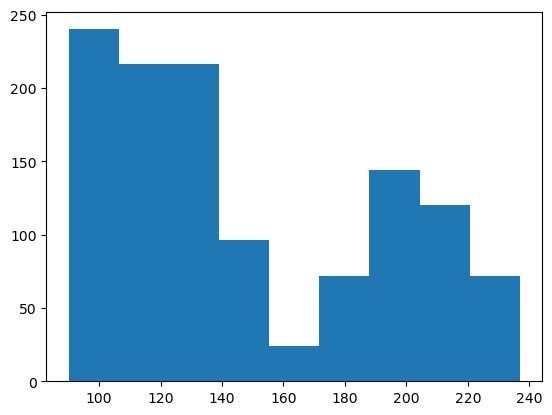

In [4]:
outs = plt.hist(target_f0s, bins=9)
counts, bins = outs[0], outs[1]
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

unique_locs = np.unique(target_locs, axis=0)
unique_f0s = np.unique(f0_bins)

unique_features = list(unique_locs) + list(unique_f0s)
# isinstance(unique_features[-1], int)
unique_features

### proof of concept: get average gains for each location

In [5]:
[k for k in layer_shape_dict.keys() if 'gain' in k]

['hann_pool_0_gains',
 'hann_pool_1_gains',
 'hann_pool_2_gains',
 'hann_pool_3_gains',
 'hann_pool_4_gains',
 'hann_pool_5_gains',
 'hann_pool_6_gains']

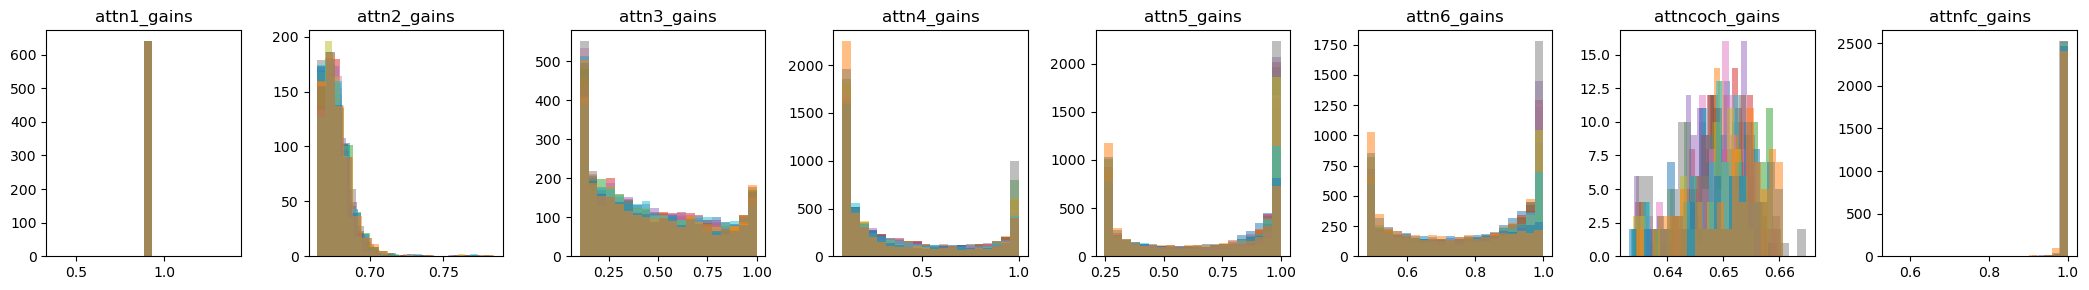

In [6]:
attn_layers = [k for k in h5.keys() if 'gains' in k]

fig, axs = plt.subplots(1, len(attn_layers), figsize=(21, 3))

for ix, layer in enumerate(attn_layers):
    gains = h5[layer][:]
    gain_avg_dict = {}
    for feature in unique_features:
        if isinstance(feature, np.int64):
            gain_ixs = (f0_bins == feature)
        else:
            gain_ixs = (target_locs == feature).all(axis=1)
        if gain_ixs.sum() == 0:
            continue
        avg_gains = gains[gain_ixs].mean(0)
        gain_avg_dict[str(feature)] = {'gains':avg_gains, 'feature':feature}

    for key,vals in gain_avg_dict.items():
        axs[ix].hist(vals['gains'], bins=20, alpha=0.5, )
        axs[ix].set_title(layer)
plt.tight_layout()

### Look at gain maps per feature

In [7]:
target_f0s

array([181.51851, 181.51851, 185.74493, ..., 111.22839,  91.09221,
        91.09221], dtype=float32)

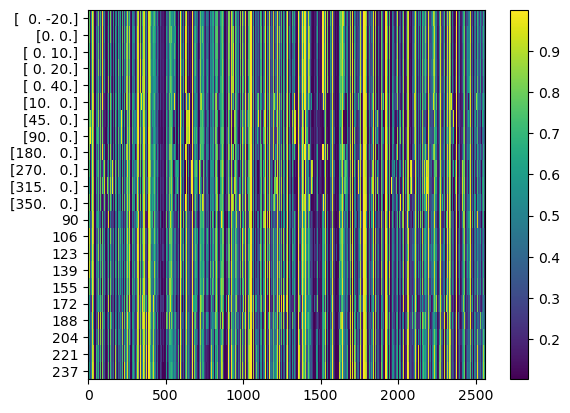

In [8]:
layer_ix = 2
channels, freq = layer_shape_dict[f"attn{layer_ix+1}"][1:3]

gains = h5[f"attn{layer_ix+1}_gains"][:]
gain_avg_dict = {}
for feature in unique_features:
    if isinstance(feature, np.int64):
        gain_ixs = (f0_bins == feature)
    else:
        gain_ixs = (target_locs == feature).all(axis=1)
    if gain_ixs.sum() == 0:
        continue
    avg_gains = gains[gain_ixs].mean(0)
    gain_avg_dict[str(feature)] = {'gains':avg_gains, 'feature':feature}

n_gain_features = len(gain_avg_dict)

# fig, ax = plt.subplots(2,n_gain_features//2, figsize=(15,5))
# ax = ax.flatten()

gains = np.array([vals['gains'].flatten() for vals in gain_avg_dict.values()])
plt.imshow(gains, aspect='auto', interpolation='none', vmin=gains.min(), vmax=gains.max())
plt.yticks(np.arange(n_gain_features), gain_avg_dict.keys());
plt.colorbar()

# for i, (key, vals) in enumerate(gain_avg_dict.items()):
#     ax[i].imshow(vals['gains'].reshape(freq, channels), aspect='auto', interpolation='none', vmin=vals['gains'].min(), vmax=vals['gains'].max())
#     ax[i].set_title(key)
# plt.tight_layout()

### Dev target act measures

In [9]:
# np.random.seed(10)
# ### Pick layer 
# layer_ix = 2 # has 640 units, so manageable for notebook

# # pick a target as example 
# target_azim = 90 
# target_ix = np.random.choice(np.argwhere(target_locs[:,0] == target_azim).flatten()).astype('int')

# target_f0 = target_f0s[target_ix]
# target_loc = target_locs[target_ix]
# print(f"Target f0: {target_f0:.2f}, Target loc: {target_loc}")

# # pick a distractor for an example at opposite location
# distractor_ix = np.random.choice(np.argwhere(target_locs[:,0] == 270).flatten()).astype('int')
# distractor_f0 = target_f0s[distractor_ix]
# distractor_loc = target_locs[distractor_ix]
# print(f"Distractor f0: {distractor_f0:.2f}, Distractor loc: {distractor_loc}")

# # gain ix is layer_ix + 1
# gains = h5[f"attn{layer_ix+1}_gains"][:]

# target_features = h5[f"hann_pool_{layer_ix}_cue"][target_ix,:]
# distractor_features = h5[f"hann_pool_{layer_ix}_cue"][distractor_ix,:]


# gain_avg_dict = {}
# for unique_loc in np.unique(target_locs, axis=0):
#     gain_ixs = (target_locs == unique_loc).all(axis=1)
#     avg_gains = gains[gain_ixs].mean(0)
    # gain_avg_dict[str(unique_loc)] = {'gains':avg_gains, 'loc':unique_loc}

9 10


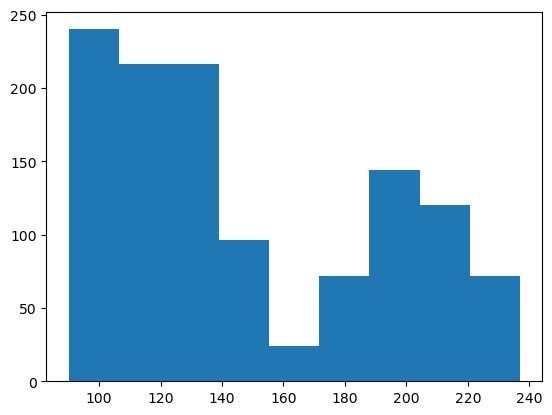

In [10]:
outs = plt.hist(target_f0s, bins=9)
counts, bins = outs[0], outs[1]
print(len(counts), len(bins))
f0_assignments = np.digitize(target_f0s, bins, right=True)
bins = bins.round(0)
f0_bins = bins[f0_assignments]
f0_bins = f0_bins.astype(int)

# group like with locations 
f0_ixs = {}
for f0 in np.unique(f0_bins):
    f0_ixs[f"{f0} Hz"] = np.where(f0_bins == f0)[0]

In [11]:
unique_locs = np.unique(target_locs, axis=0)
unique_f0s = np.unique(f0_bins)

unique_features = list(unique_locs) + list(unique_f0s)
# isinstance(unique_features[-1], int)
unique_features

[array([  0., -20.], dtype=float32),
 array([0., 0.], dtype=float32),
 array([ 0., 10.], dtype=float32),
 array([ 0., 20.], dtype=float32),
 array([ 0., 40.], dtype=float32),
 array([10.,  0.], dtype=float32),
 array([45.,  0.], dtype=float32),
 array([90.,  0.], dtype=float32),
 array([180.,   0.], dtype=float32),
 array([270.,   0.], dtype=float32),
 array([315.,   0.], dtype=float32),
 array([350.,   0.], dtype=float32),
 90,
 106,
 123,
 139,
 155,
 172,
 188,
 204,
 221,
 237]

In [12]:
target_ixs

NameError: name 'target_ixs' is not defined

In [72]:
# get act selectivity ratio 

def unit_act_ratio(target, distractor):
    """Get log ratio of target and distractor activations per unit"""
    ratios = np.log(target) - np.log(distractor)
    # set nans and infs to 0 - dead units stay 0 this way 
    ratios = np.nan_to_num(ratios, nan=0, posinf=0, neginf=0)
    return ratios

def get_act_delta(target_features, gains):
    q_feats = gains * target_features
    act_delta = (q_feats - target_features ) / np.abs(target_features)
    return act_delta

def get_unit_act_deltas(target_features, distractor_features, gains):
    unit_act_ratios = unit_act_ratio(target_features, distractor_features)
    unit_rank = np.argsort(unit_act_ratios)[::-1]
    unit_act_deltas = get_act_delta(target_features, gains)
    return unit_act_deltas[unit_rank]


# unit_act_ratios = unit_act_ratio(target_features, distractor_features)
# # rank units by selectivity
# unit_rank = np.argsort(unit_act_ratios)[::-1]

# get diverging color map so elements with unit_act_ratio > 0 are one color, and < 0 are another 
# avg_feature_gains = gain_avg_dict[str(target_locs[target_ix])]

# eg target azim:

examp_ixs = np.arange(target_locs.shape[0])
# colors = sns.color_palette("PiYG", n_colors=n_units)
# colors = np.array(colors)

layer_results_dict = {}
for layer_ix in range(7):
    print(layer_ix)
    n_units = h5[f"hann_pool_{layer_ix}_cue"].shape[1]
    # gain ix is layer_ix + 1
    if layer_ix == 6:
        gains = h5[f"attnfc_gains"][:]
    else:
        gains = h5[f"attn{layer_ix+1}_gains"][:]
    gain_avg_dict = {}
    for unique_feat in unique_features:
        if isinstance(unique_feat, np.int64):
            gain_ixs = (f0_bins == unique_feat)
        else:
            gain_ixs = (target_locs == unique_feat).all(axis=1)
        avg_gains = gains[gain_ixs].mean(0)
        gain_avg_dict[str(unique_feat)] = {'gains':avg_gains, 'feature':unique_feat}

    feat_delta_dict = {}
    for feat_key, feat_vals in gain_avg_dict.items():
        avg_feature_gains = feat_vals['gains']
        feature = feat_vals['feature']
        if isinstance(feature, np.int64):
            target_ixs = np.where(f0_bins == feature)[0]
        else:
            target_ixs = np.where((target_locs == feature).all(axis=1))[0]
        unit_act_deltas = np.zeros((len(target_ixs), n_units))

        valid_distractor_ixs = np.delete(examp_ixs, target_ixs)

        for ix, target_ix in enumerate(target_ixs):
            target_features = h5[f"hann_pool_{layer_ix}_cue"][target_ix,:]
            distractor_ix = np.random.choice(valid_distractor_ixs).astype('int')
            distractor_features = h5[f"hann_pool_{layer_ix}_cue"][distractor_ix,:]
            unit_act_deltas[ix] = get_unit_act_deltas(target_features, distractor_features, avg_feature_gains)

        unit_act_deltas_avg = unit_act_deltas.mean(0)
        feat_delta_dict[feat_key] = unit_act_deltas_avg
    layer_results_dict[f"Layer {layer_ix}"] = feat_delta_dict
    # print(feat_delta_dict)

# plt.figure()

# plt.bar(np.arange(n_units), unit_act_deltas, alpha=0.5, color=colors)


0


/tmp/ipykernel_88164/2987869986.py:5: RuntimeWarning: divide by zero encountered in log
  ratios = np.log(target) - np.log(distractor)
/tmp/ipykernel_88164/2987869986.py:12: RuntimeWarning: invalid value encountered in divide
  act_delta = (q_feats - target_features ) / np.abs(target_features)


1


/tmp/ipykernel_88164/2987869986.py:5: RuntimeWarning: invalid value encountered in subtract
  ratios = np.log(target) - np.log(distractor)


2
3
4
5
6


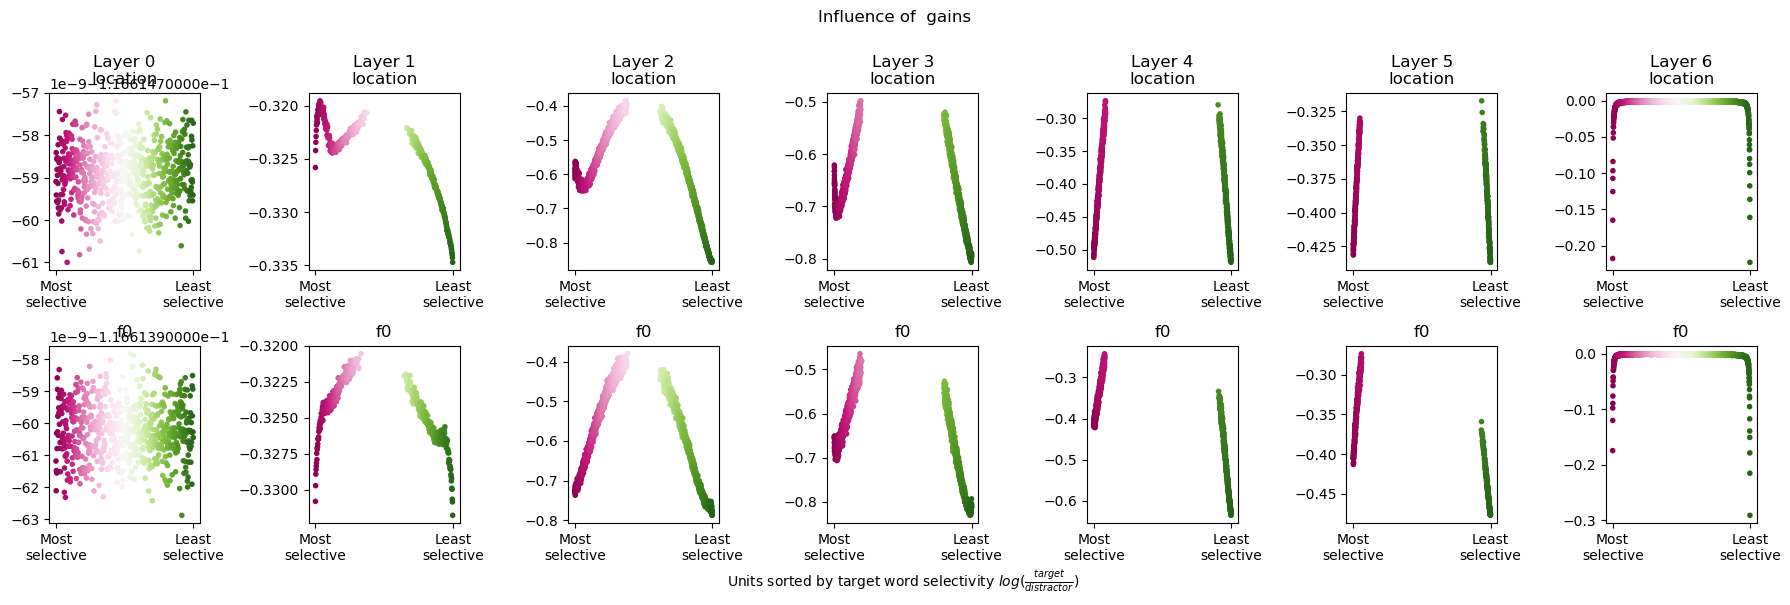

In [74]:
### Plot results for each layer 

## plot average deltas across keys 
fig, axs = plt.subplots(2,7, figsize=(18,6))

for ix, (layer, results) in enumerate(layer_results_dict.items()):
    global_avg_loc_deltas = np.array([vals for k, vals in results.items() if k.startswith('[')]).mean(0)
    global_avg_f0_deltas = np.array([vals for k, vals in results.items() if not k.startswith('[')]).mean(0)

    n_units = global_avg_loc_deltas.shape[0]
    colors = sns.color_palette("PiYG", n_colors=n_units)
    colors = np.array(colors)
    axs[0, ix].scatter(np.arange(n_units), global_avg_loc_deltas, color=colors,  marker='.')
    axs[1, ix].scatter(np.arange(n_units), global_avg_f0_deltas,  color=colors,  marker='.')
    axs[0,ix].set_title(f"{layer}\nlocation")
    axs[1,ix].set_title(f"f0")

    for ax in axs[:,ix]:
        ax.set_xticks([0, n_units])
        ax.set_xticklabels(['Most\nselective', 'Least\nselective'])
        # ax.set_ylim(0,1.01)
        # ax.set_ylabel("Relative reduction\nin activation");
    if ix == 3:
        axs[1,ix].set_xlabel("Units sorted by target word selectivity $log(\\frac{target}{distractor})$")
    # if ix == 0:
        # set as text between two rows 
# axs[0,0].set_ylabel( "Relative reduction in activation $(\\frac{attended - unattended}{unattended})$", rotation=90, va='center', ha='center', labelpad=20, y = -0.5)
# axs[0,0].set_ylabel( "Modulation in activation $(\\frac{attended}{unattended})$", rotation=90, va='center', ha='center', labelpad=20, y = -0.5)
plt.suptitle("Influence of  gains", y=1)
# fig.text( 1, 0, "Relative reduction in activation $(\\frac{attended - unattended}{unattended})$", rotation=90, va='center', ha='center')


plt.tight_layout()
# 

In [ ]:
## plot output of deltas for each key 

fig, axs = plt.subplots(3, len(feat_delta_dict)//3, figsize=(20, 5))
axs = axs.flatten()
x = np.arange(n_units)
for i, (key, vals) in enumerate(feat_delta_dict.items()):
    axs[i].bar(x, vals, alpha=0.5, color=colors)
    axs[i].set_title(key)
plt.tight_layout()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x14c8cd406670> (for post_execute):


KeyboardInterrupt: 

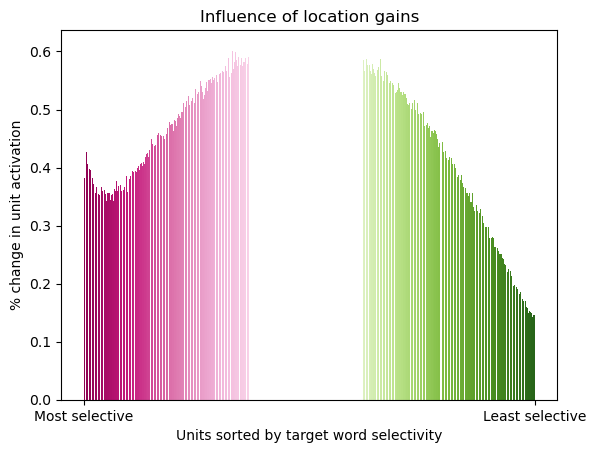

In [79]:
## plot average deltas across keys 

global_avg_deltas = np.array([vals for vals in feat_delta_dict.values()]).mean(0)
plt.figure()
x = np.arange(n_units)
plt.bar(x, global_avg_deltas,  color=colors)
plt.title("Influence of location gains")
# set xticks at 0 and max 
plt.xticks([0, n_units], ['Most selective', 'Least selective'])
plt.xlabel("Units sorted by target word selectivity")
plt.ylabel("% change in unit activation");


## Run for all layers

In [ ]:
## Implement above, but for all layers in the network (ixs 0 - 6 )
